# Entradas de poço variáveis no tempo: `testNewWell/Peaceman`

O `wellModel` bifásico agora lê cada entrada de poço (`rate` ou `bhp`, `Fb_inj`, `Cs_inj`) como uma `Function1<scalar>` da OpenFOAM 9, selecionada por `type` no `constant/wellProperties`, e reavalia essas entradas no início de cada passo de tempo (`updateWellInputs(runTime.value())`). Um número puro continua válido e é lido como `constant`.

Este notebook usa o `uqtopus` para renderizar o caso `testNewWell/Peaceman` com três formas de prescrever o `Fb_inj` do `injector1`, rodar as três em paralelo e comparar:

| cenário | `Fb_inj` do `injector1` |
|---|---|
| `constante` | `0.0;` (o caso original) |
| `rampa` | `{ type table; values ((0 0) (T 1)); }` |
| `slug` | `{ type square; level 0.5; amplitude 0.5; frequency 1/P; }`, alterna entre 1 e 0 com período `P` |

Os outros poços (`injector2` e `producer1`) ficam como no caso original.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import uqtopus as uqt

CASE_DIR = Path.cwd()
TEMPLATE = CASE_DIR / 'template'
EXPERIMENTS = CASE_DIR / 'experiments'

END_TIME = 5e7        # endTime do caso original
WRITE_INTERVAL = 5e5  # gravações mais frequentes que o original (1e6) para resolver o slug
SLUG_PERIOD = 1e7

INJ1_CELLS = [51, 103, 155]
PROD1_CELL = 2600

print('uqtopus em', Path(uqt.__file__).parent)

uqtopus em /home/gbm/projects/UQTOPUS/src/uqtopus


Cada cenário é só o texto que entra no lugar de `{{ Fb_inj_injector1 }}` em `template/constant/wellProperties`.

In [2]:
SCENARIOS = {
    'constante': '0.0;',
    'rampa': f'{{ type table; values ((0 0) ({END_TIME:g} 1)); }}',
    'slug': f'{{ type square; level 0.5; amplitude 0.5; frequency {1/SLUG_PERIOD:g}; markSpace 1; }}',
}


def fb_expected(name, t):
    t = np.asarray(t, dtype=float)
    if name == 'constante':
        return np.zeros_like(t)
    if name == 'rampa':
        return np.clip(t/END_TIME, 0, 1)
    if name == 'slug':
        return np.where((t/SLUG_PERIOD) % 1 < 0.5, 1.0, 0.0)
    raise KeyError(name)


params_list = [
    {
        'constant__wellProperties__Fb_inj_injector1': entry,
        'system__controlDict__end_time': f'{END_TIME:g}',
        'system__controlDict__write_interval': f'{WRITE_INTERVAL:g}',
    }
    for entry in SCENARIOS.values()
]
for name, p in zip(SCENARIOS, params_list):
    print(f"{name:>10}: Fb_inj {p['constant__wellProperties__Fb_inj_injector1']}")

 constante: Fb_inj 0.0;
     rampa: Fb_inj { type table; values ((0 0) (5e+07 1)); }
      slug: Fb_inj { type square; level 0.5; amplitude 0.5; frequency 1e-07; markSpace 1; }


## Runs

In [3]:
write_times = list(np.arange(WRITE_INTERVAL, END_TIME + 0.5*WRITE_INTERVAL, WRITE_INTERVAL))

sim = uqt.OpenFOAMSimulator(
    template_path=TEMPLATE,
    solver_script='Allrun',
    output_path=EXPERIMENTS,
    qoi_variables=['qt', 'qb', 'Sb'],
    qoi_times=write_times,
    experiment_name='Fb_inj',
)
datasets = sim.run_batch(params_list, n_jobs=len(params_list))
results = dict(zip(SCENARIOS, datasets))
results['rampa']


Running parallel batch:   0%|          | 0/3 [00:00<?, ?it/s]


Running parallel batch:  33%|███▎      | 1/3 [07:50<15:41, 470.79s/it]


Running parallel batch:  67%|██████▋   | 2/3 [07:54<03:16, 196.27s/it]


Running parallel batch: 100%|██████████| 3/3 [07:55<00:00, 106.77s/it]


Running parallel batch: 100%|██████████| 3/3 [07:55<00:00, 158.39s/it]

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 100, cell: 2601)
Coordinates:
  * time     (time) float64 800B 5e+05 1e+06 1.5e+06 ... 4.9e+07 4.95e+07 5e+07
    x        (cell) float64 21kB 1.395 4.184 6.973 9.762 ... 135.3 138.1 140.9
    y        (cell) float64 21kB 1.395 1.395 1.395 1.395 ... 140.9 140.9 140.9
    z        (cell) float64 21kB 5.0 5.0 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0 5.0 5.0
Dimensions without coordinates: cell
Data variables:
    qt       (time, cell) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 -2.571e-06
    qb       (time, cell) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 -1.891e-06
    Sb       (time, cell) float64 2MB 0.6425 0.6625 0.6758 ... 0.6236 0.6139

## O valor prescrito chegou ao solver?

Nas células do `injector1` o solver faz `qb = Fb_inj*qt`, então `qb/qt` nessas células é o `Fb_inj` que foi de fato aplicado em cada gravação. Os pontos devem cair sobre a função prescrita.

 constante: erro máximo |qb/qt - prescrito| = 0.00e+00
     rampa: erro máximo |qb/qt - prescrito| = 1.77e-06
      slug: erro máximo |qb/qt - prescrito| = 0.00e+00


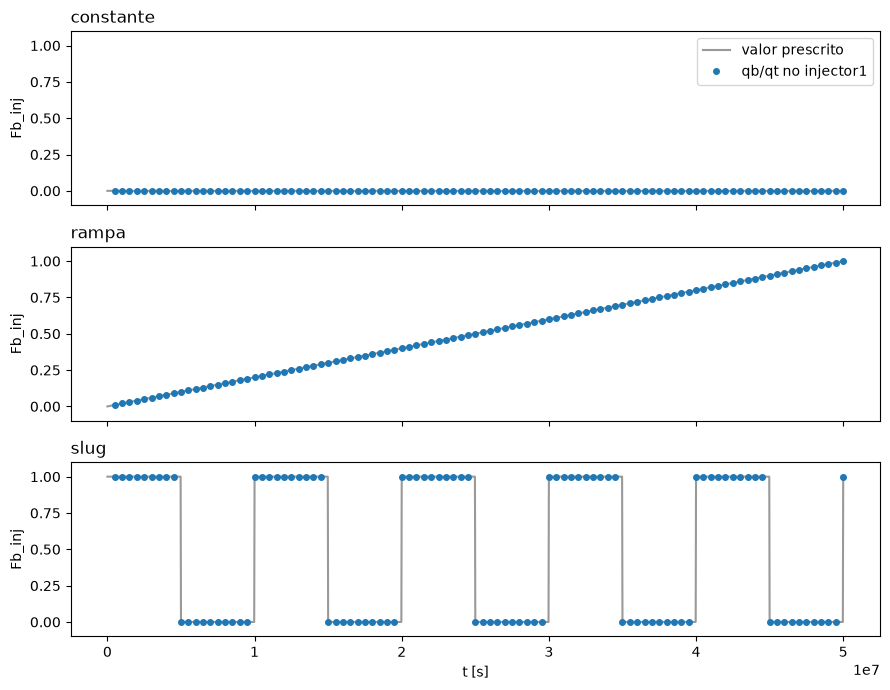

In [4]:
fig, axes = plt.subplots(len(results), 1, figsize=(9, 7), sharex=True)
t_fine = np.linspace(0, END_TIME, 2001)
max_err = {}
for ax, (name, ds) in zip(axes, results.items()):
    t = ds.time.values
    fb_applied = (ds.qb[:, INJ1_CELLS] / ds.qt[:, INJ1_CELLS]).mean('cell').values
    max_err[name] = np.max(np.abs(fb_applied - fb_expected(name, t)))
    ax.plot(t_fine, fb_expected(name, t_fine), color='0.6', lw=1.5, label='valor prescrito')
    ax.plot(t, fb_applied, 'o', ms=4, label='qb/qt no injector1')
    ax.set_ylabel('Fb_inj')
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(name, loc='left')
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('t [s]')
fig.tight_layout()

for name, err in max_err.items():
    print(f'{name:>10}: erro máximo |qb/qt - prescrito| = {err:.2e}')

## Resposta no produtor

Fração da fase b produzida (`qb/qt` na célula do `producer1`) para os três cenários.

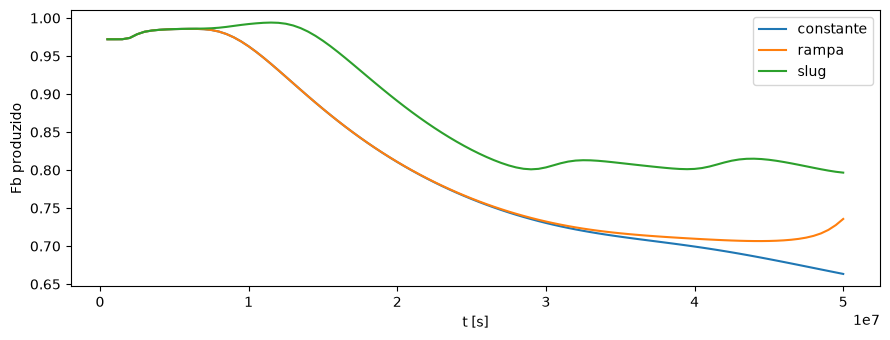

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for name, ds in results.items():
    ax.plot(ds.time.values, (ds.qb[:, PROD1_CELL] / ds.qt[:, PROD1_CELL]).values, label=name)
ax.set_xlabel('t [s]')
ax.set_ylabel('Fb produzido')
ax.legend()
fig.tight_layout()

## Saturação `Sb` no instante final

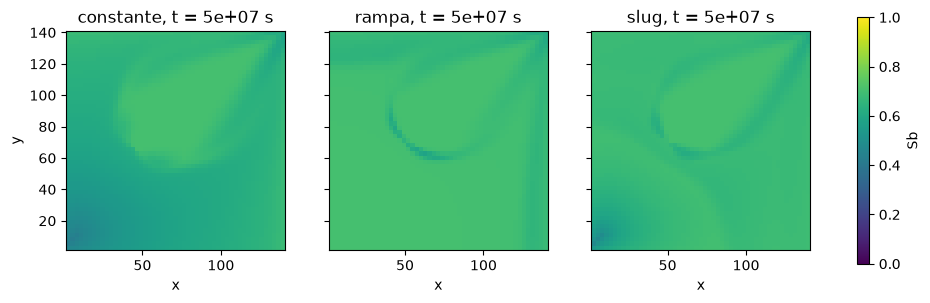

In [6]:
fig, axes = plt.subplots(1, len(results), figsize=(12, 4), sharey=True)
for ax, (name, ds) in zip(axes, results.items()):
    x, y = ds.x.values, ds.y.values
    nx, ny = len(np.unique(np.round(x, 6))), len(np.unique(np.round(y, 6)))
    order = np.lexsort((x, y))
    sb = ds.Sb.isel(time=-1).values[order].reshape(ny, nx)
    im = ax.imshow(sb, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1, cmap='viridis')
    ax.set_title(f'{name}, t = {ds.time.values[-1]:g} s')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im, ax=axes, label='Sb', shrink=0.8)